# Imports

In [1]:
import os
import sqlite3

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import lightgbm as lgb
import optuna
import shap
import umap
import hdbscan

from joblib import dump, load
from sklearn.metrics import (
    classification_report,
    fbeta_score,
    f1_score,
    recall_score,
)
from sklearn.model_selection import StratifiedKFold, train_test_split

optuna.logging.set_verbosity(optuna.logging.WARNING)

/home/linkezio/Projects/A Hierarchical MEC and IoT Solution for Cyber-Attack Detection in 6G Networks/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Constants

In [2]:
RANDOM_SEED = 42

# Inputs

In [3]:
DB_PATH = "../data/sqlite/data.db"
TABLE   = "network_data"

# Samples per class (defined by the `label` column).
# - int  → same cap for every class
# - None → all available data (careful: may crash on large datasets)
SAMPLES_PER_CLASS: int | None = 10_000
# Per-class overrides — take precedence over SAMPLES_PER_CLASS.
SAMPLES_PER_CLASS_OVERRIDE: dict = {}  # e.g. {"benign": 20_000}

# Binary sampling: (n_benign, n_attack) — overrides SAMPLES_PER_CLASS when set.
# Loads n_benign rows from BENIGN_LABEL and n_attack rows from all other
# classes combined, distributed evenly across attack classes.
# Set to None to fall back to SAMPLES_PER_CLASS.
BINARY_SAMPLING: tuple[int, int] | None = (400_000, 400_000)

BENIGN_LABEL: str = "benign"

In [4]:
import os as _os
from datetime import datetime as _dt

_ts = _dt.now().strftime("%Y%m%d_%H%M%S")
_report_path = f"../docs/results/training_{_ts}.md"
_report_start = _dt.now()
_os.makedirs(_os.path.dirname(_report_path), exist_ok=True)

def _report_append(text: str) -> None:
    with open(_report_path, "a") as _f:
        _f.write(text)

_report_append(
    f"# Training Results — {_dt.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n"
    f"## Configuration\n\n"
    f"| Parameter | Value |\n"
    f"|-----------|-------|\n"
    f"| Random seed | `{RANDOM_SEED}` |\n"
    f"| DB path | `{DB_PATH}` |\n"
    f"| Table | `{TABLE}` |\n"
    f"| Samples per class | `{SAMPLES_PER_CLASS}` |\n"
    f"| Binary sampling (benign, attack) | `{BINARY_SAMPLING}` |\n"
    f"| Benign label | `{BENIGN_LABEL}` |\n\n"
)
print(f"[report] Initialized → {_report_path}")

[report] Initialized → ../docs/results/training_20260517_115543.md


# Data

## Load Data

In [5]:
def load_dataset_from_db(
    db_path: str,
    table: str,
    samples_per_class: "int | None" = None,
    override: dict = {},
    binary_sampling: "tuple[int, int] | None" = None,
    benign_label: str = "benign",
) -> pd.DataFrame:
    """
    Load data from SQLite, sampling per class directly in the DB so that
    only the selected rows are pulled into memory.

    SQLite handles sampling with ORDER BY RANDOM() LIMIT n, avoiding the
    need to load the full dataset into pandas before filtering.

    When binary_sampling=(n_benign, n_attack) is provided, samples n_benign
    rows from benign_label and distributes n_attack evenly across all attack
    classes (n_attack // num_attack_classes per class), ignoring
    samples_per_class and override.
    """
    conn = sqlite3.connect(db_path)

    if binary_sampling is not None:
        n_benign, n_attack = binary_sampling

        q_benign = f'SELECT * FROM "{table}" WHERE label = ? ORDER BY RANDOM() LIMIT ?'
        df_benign = pd.read_sql(q_benign, conn, params=(benign_label, n_benign))
        print(f"  {benign_label}: {len(df_benign):,} rows")

        attack_classes = pd.read_sql(
            f'SELECT DISTINCT label FROM "{table}" WHERE label != ? AND label IS NOT NULL',
            conn, params=(benign_label,)
        )["label"].tolist()

        n_per_class = n_attack // len(attack_classes)
        attack_frames = []
        for cls in sorted(attack_classes):
            q_cls = f'SELECT * FROM "{table}" WHERE label = ? ORDER BY RANDOM() LIMIT ?'
            df_cls = pd.read_sql(q_cls, conn, params=(cls, n_per_class))
            attack_frames.append(df_cls)
            print(f"  {cls}: {len(df_cls):,} rows")

        conn.close()
        result = pd.concat([df_benign] + attack_frames, ignore_index=True).sample(frac=1, random_state=RANDOM_SEED)
        print(f"\nTotal: {len(result):,} rows")
        return result

    classes = pd.read_sql(
        f'SELECT DISTINCT label FROM "{table}" WHERE label IS NOT NULL', conn
    )["label"].tolist()
    print(f"Classes: {sorted(classes)}")

    frames = []
    for cls in classes:
        n = override.get(cls, samples_per_class)

        if n is None:
            query = f'SELECT * FROM "{table}" WHERE label = ?'
            df_cls = pd.read_sql(query, conn, params=(cls,))
        else:
            query = f'SELECT * FROM "{table}" WHERE label = ? ORDER BY RANDOM() LIMIT ?'
            df_cls = pd.read_sql(query, conn, params=(cls, n))

        frames.append(df_cls)
        print(f"  {cls}: {len(df_cls):,} rows")

    conn.close()

    result = pd.concat(frames, ignore_index=True).sample(frac=1, random_state=RANDOM_SEED)
    print(f"\nTotal: {len(result):,} rows")
    return result

In [6]:
def load_dataset_from_csv(
    data_root: str,
    dataset: str,
    samples_per_class: "int | None" = None,
    override: dict = {},
    random_state: int = 42,
) -> pd.DataFrame:
    """
    Alternative: load from CSV files directly.
    Only use for small datasets — large ones will exhaust RAM.
    """
    import glob
    dataset_path = os.path.join(data_root, dataset)
    csv_paths = sorted(glob.glob(os.path.join(dataset_path, "**", "*.csv"), recursive=True))
    if not csv_paths:
        raise FileNotFoundError(f"No CSVs found in: {dataset_path}")

    df = pd.concat((pd.read_csv(p) for p in csv_paths), ignore_index=True)

    if samples_per_class is None and not override:
        return df

    sampled = []
    for cls in df["label"].unique():
        n = override.get(cls, samples_per_class)
        cls_df = df[df["label"] == cls]
        sampled.append(cls_df.sample(min(n, len(cls_df)), random_state=random_state) if n else cls_df)

    return pd.concat(sampled, ignore_index=True).sample(frac=1, random_state=random_state)

In [7]:
df = load_dataset_from_db(
    DB_PATH,
    TABLE,
    samples_per_class=SAMPLES_PER_CLASS,
    override=SAMPLES_PER_CLASS_OVERRIDE,
    binary_sampling=BINARY_SAMPLING,
    benign_label=BENIGN_LABEL,
)
df.head()

  benign: 400,000 rows
  bruteforce: 16,397 rows
  ddos: 50,000 rows
  dos: 50,000 rows
  malware: 50,000 rows
  mitm: 50,000 rows
  recon: 50,000 rows
  spoofing: 50,000 rows
  web: 50,000 rows

Total: 766,397 rows


,src_ip,dst_ip,src_port,dst_port,protocol,timestamp,flow_duration,flow_byts_s,flow_pkts_s,fwd_pkts_s,...,active_max,active_min,active_mean,active_std,idle_max,idle_min,idle_mean,idle_std,cwr_flag_count,label
320978,192.168.1.1,224.0.0.251,34812,5353,17,1.757468e+09,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0,benign
73590,157.249.81.141,192.168.137.41,443,51935,6,1.665164e+09,0.001216,134053.245490,2467.237647,2467.237647,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0,benign
66329,192.168.137.227,8.8.8.8,44813,53,17,1.665214e+09,0.070509,3488.918441,28.365191,14.182595,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0,benign
13908,192.168.137.253,8.8.8.8,52806,53,17,1.665234e+09,350.823777,49.931051,0.302146,0.151073,...,19.314835,0.101626,2.534546,4.135685,47.71198,5.054612,13.406648,10.204086,0,benign
533318,192.168.137.120,8.8.8.8,55710,53,17,1.673537e+09,0.124152,1095.431891,16.109293,8.054646,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0,malware


In [8]:
_class_counts = df["label"].value_counts().sort_index()
_counts_rows = "\n".join(f"| `{c}` | {n:,} |" for c, n in _class_counts.items())
_report_append(
    f"## Dataset\n\n"
    f"Raw shape after load: `{df.shape}`\n\n"
    f"| Class | Rows |\n"
    f"|-------|------|\n"
    f"{_counts_rows}\n"
    f"| **Total** | **{len(df):,}** |\n\n"
)
print("[report] Dataset section written.")

[report] Dataset section written.


## Data Cleaning

### Removing useless features

Some columns were discarded because they do not provide useful information
for training, or because they bias the model:
- **timestamp**: encodes the data collection time, not network behaviour.
  Including it would cause the model to memorize recording sessions rather
  than learn traffic patterns.
- **src\_ip / dst\_ip** (commented out): can be re-enabled if topological
  features are desired, but they add risk of dataset-specific overfitting.

In [9]:
removed_features: dict[str, list[str]] = {}

print("Before:")
print(f"  Shape: {df.shape}")
print(f"  Columns: {list(df.columns)}")

USELESS_FEATURES = ["timestamp", "src_ip", "dst_ip", "scr_port", "dst_port"]
actually_dropped = [c for c in USELESS_FEATURES if c in df.columns]
df = df.drop(columns=actually_dropped)
removed_features["useless_features"] = actually_dropped

print("\nAfter:")
print(f"  Shape: {df.shape}")
print(f"  Columns: {list(df.columns)}")

Before:
  Shape: (766397, 83)
  Columns: ['src_ip', 'dst_ip', 'src_port', 'dst_port', 'protocol', 'timestamp', 'flow_duration', 'flow_byts_s', 'flow_pkts_s', 'fwd_pkts_s', 'bwd_pkts_s', 'tot_fwd_pkts', 'tot_bwd_pkts', 'totlen_fwd_pkts', 'totlen_bwd_pkts', 'fwd_pkt_len_max', 'fwd_pkt_len_min', 'fwd_pkt_len_mean', 'fwd_pkt_len_std', 'bwd_pkt_len_max', 'bwd_pkt_len_min', 'bwd_pkt_len_mean', 'bwd_pkt_len_std', 'pkt_len_max', 'pkt_len_min', 'pkt_len_mean', 'pkt_len_std', 'pkt_len_var', 'fwd_header_len', 'bwd_header_len', 'fwd_seg_size_min', 'fwd_act_data_pkts', 'flow_iat_mean', 'flow_iat_max', 'flow_iat_min', 'flow_iat_std', 'fwd_iat_tot', 'fwd_iat_max', 'fwd_iat_min', 'fwd_iat_mean', 'fwd_iat_std', 'bwd_iat_tot', 'bwd_iat_max', 'bwd_iat_min', 'bwd_iat_mean', 'bwd_iat_std', 'fwd_psh_flags', 'bwd_psh_flags', 'fwd_urg_flags', 'bwd_urg_flags', 'fin_flag_cnt', 'syn_flag_cnt', 'rst_flag_cnt', 'psh_flag_cnt', 'ack_flag_cnt', 'urg_flag_cnt', 'ece_flag_cnt', 'down_up_ratio', 'pkt_size_avg', 'fwd_se

### Strip column-name whitespace

In [10]:
spaces_before = [c for c in df.columns if c != c.strip()]
print("Before - columns with spaces:", spaces_before)

df.columns = df.columns.str.strip()

spaces_after = [c for c in df.columns if c != c.strip()]
print("After  - columns with spaces:", spaces_after)
df.head()

Before - columns with spaces: []
After  - columns with spaces: []


,src_port,protocol,flow_duration,flow_byts_s,flow_pkts_s,fwd_pkts_s,bwd_pkts_s,tot_fwd_pkts,tot_bwd_pkts,totlen_fwd_pkts,...,active_max,active_min,active_mean,active_std,idle_max,idle_min,idle_mean,idle_std,cwr_flag_count,label
320978,34812,17,0.000000,0.000000,0.000000,0.000000,0.000000,1,0,71,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0,benign
73590,443,6,0.001216,134053.245490,2467.237647,2467.237647,0.000000,3,0,163,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0,benign
66329,44813,17,0.070509,3488.918441,28.365191,14.182595,14.182595,1,1,82,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0,benign
13908,52806,17,350.823777,49.931051,0.302146,0.151073,0.151073,53,53,3591,...,19.314835,0.101626,2.534546,4.135685,47.71198,5.054612,13.406648,10.204086,0,benign
533318,55710,17,0.124152,1095.431891,16.109293,8.054646,8.054646,1,1,60,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0,malware


### Remove invalid values (NaN / Inf)

In [11]:
numeric_df = df.select_dtypes(include="number")

print("Before:")
print(f"  Shape: {df.shape}")
print(f"  NaN count:  {df.isna().sum().sum()}")
print(f"  Inf count:  {np.isinf(numeric_df).sum().sum()}")

df = df.replace([np.inf, -np.inf], np.nan).dropna()

numeric_df = df.select_dtypes(include="number")
print("\nAfter:")
print(f"  Shape: {df.shape}")
print(f"  NaN count:  {df.isna().sum().sum()}")
print(f"  Inf count:  {np.isinf(numeric_df).sum().sum()}")
df.head()

Before:
  Shape: (766397, 79)
  NaN count:  0
  Inf count:  0

After:
  Shape: (766397, 79)
  NaN count:  0
  Inf count:  0


,src_port,protocol,flow_duration,flow_byts_s,flow_pkts_s,fwd_pkts_s,bwd_pkts_s,tot_fwd_pkts,tot_bwd_pkts,totlen_fwd_pkts,...,active_max,active_min,active_mean,active_std,idle_max,idle_min,idle_mean,idle_std,cwr_flag_count,label
320978,34812,17,0.000000,0.000000,0.000000,0.000000,0.000000,1,0,71,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0,benign
73590,443,6,0.001216,134053.245490,2467.237647,2467.237647,0.000000,3,0,163,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0,benign
66329,44813,17,0.070509,3488.918441,28.365191,14.182595,14.182595,1,1,82,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0,benign
13908,52806,17,350.823777,49.931051,0.302146,0.151073,0.151073,53,53,3591,...,19.314835,0.101626,2.534546,4.135685,47.71198,5.054612,13.406648,10.204086,0,benign
533318,55710,17,0.124152,1095.431891,16.109293,8.054646,8.054646,1,1,60,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0,malware


### Remove duplicate rows

In [12]:
print("Before:")
print(f"  Shape: {df.shape}")
print(f"  Duplicate rows: {df.duplicated().sum()}")

df = df.drop_duplicates()

print("\nAfter:")
print(f"  Shape: {df.shape}")
print(f"  Duplicate rows: {df.duplicated().sum()}")
df.head()

Before:
  Shape: (766397, 79)
  Duplicate rows: 153691

After:
  Shape: (612706, 79)
  Duplicate rows: 0


,src_port,protocol,flow_duration,flow_byts_s,flow_pkts_s,fwd_pkts_s,bwd_pkts_s,tot_fwd_pkts,tot_bwd_pkts,totlen_fwd_pkts,...,active_max,active_min,active_mean,active_std,idle_max,idle_min,idle_mean,idle_std,cwr_flag_count,label
320978,34812,17,0.000000,0.000000,0.000000,0.000000,0.000000,1,0,71,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0,benign
73590,443,6,0.001216,134053.245490,2467.237647,2467.237647,0.000000,3,0,163,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0,benign
66329,44813,17,0.070509,3488.918441,28.365191,14.182595,14.182595,1,1,82,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0,benign
13908,52806,17,350.823777,49.931051,0.302146,0.151073,0.151073,53,53,3591,...,19.314835,0.101626,2.534546,4.135685,47.71198,5.054612,13.406648,10.204086,0,benign
533318,55710,17,0.124152,1095.431891,16.109293,8.054646,8.054646,1,1,60,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0,malware


### Remove highly correlated features

Features with pairwise Pearson correlation > `CORR_THRESHOLD` add
redundant information and can slow training without improving accuracy.
We keep the first feature of each correlated pair (upper-triangle scan).

In [13]:
CORR_THRESHOLD = 0.95

numeric_cols = df.select_dtypes(include="number").columns.tolist()
print("Before:")
print(f"  Shape: {df.shape}")

corr_matrix = df[numeric_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > CORR_THRESHOLD)]
print(f"  Dropped (corr > {CORR_THRESHOLD}): {to_drop}")

df = df.drop(columns=to_drop)
removed_features["high_correlation"] = to_drop

print("\nAfter:")
print(f"  Shape: {df.shape}")
df.head()

Before:
  Shape: (612706, 79)
  Dropped (corr > 0.95): ['fwd_pkts_s', 'totlen_fwd_pkts', 'fwd_seg_size_min', 'fwd_act_data_pkts', 'fwd_iat_tot', 'fwd_iat_max', 'psh_flag_cnt', 'ack_flag_cnt', 'pkt_size_avg', 'fwd_seg_size_avg', 'bwd_seg_size_avg', 'active_std', 'idle_max', 'idle_mean']

After:
  Shape: (612706, 65)


,src_port,protocol,flow_duration,flow_byts_s,flow_pkts_s,bwd_pkts_s,tot_fwd_pkts,tot_bwd_pkts,totlen_bwd_pkts,fwd_pkt_len_max,...,subflow_bwd_byts,init_fwd_win_byts,init_bwd_win_byts,active_max,active_min,active_mean,idle_min,idle_std,cwr_flag_count,label
320978,34812,17,0.000000,0.000000,0.000000,0.000000,1,0,0,71,...,0,-1,-1,0.000000,0.000000,0.000000,0.000000,0.000000,0,benign
73590,443,6,0.001216,134053.245490,2467.237647,0.000000,3,0,0,59,...,0,508,-1,0.000000,0.000000,0.000000,0.000000,0.000000,0,benign
66329,44813,17,0.070509,3488.918441,28.365191,14.182595,1,1,164,82,...,164,-1,-1,0.000000,0.000000,0.000000,0.000000,0.000000,0,benign
13908,52806,17,350.823777,49.931051,0.302146,0.151073,53,53,13926,76,...,348,-1,-1,19.314835,0.101626,2.534546,5.054612,10.204086,0,benign
533318,55710,17,0.124152,1095.431891,16.109293,8.054646,1,1,76,60,...,76,-1,-1,0.000000,0.000000,0.000000,0.000000,0.000000,0,malware


### Remove near-zero variance features

Features whose variance is below `VARIANCE_THRESHOLD` carry almost no
discriminative signal and can cause numerical instability in some learners.

In [14]:
VARIANCE_THRESHOLD = 1e-4

numeric_cols = df.select_dtypes(include="number").columns.tolist()
print("Before:")
print(f"  Shape: {df.shape}")

variances = df[numeric_cols].var()
low_var_cols = variances[variances < VARIANCE_THRESHOLD].index.tolist()
print(f"  Dropped (var < {VARIANCE_THRESHOLD}): {low_var_cols}")

df = df.drop(columns=low_var_cols)
removed_features["near_zero_variance"] = low_var_cols

print("\nAfter:")
print(f"  Shape: {df.shape}")
df.head()

Before:
  Shape: (612706, 65)
  Dropped (var < 0.0001): ['fwd_urg_flags', 'bwd_urg_flags', 'urg_flag_cnt']

After:
  Shape: (612706, 62)


,src_port,protocol,flow_duration,flow_byts_s,flow_pkts_s,bwd_pkts_s,tot_fwd_pkts,tot_bwd_pkts,totlen_bwd_pkts,fwd_pkt_len_max,...,subflow_bwd_byts,init_fwd_win_byts,init_bwd_win_byts,active_max,active_min,active_mean,idle_min,idle_std,cwr_flag_count,label
320978,34812,17,0.000000,0.000000,0.000000,0.000000,1,0,0,71,...,0,-1,-1,0.000000,0.000000,0.000000,0.000000,0.000000,0,benign
73590,443,6,0.001216,134053.245490,2467.237647,0.000000,3,0,0,59,...,0,508,-1,0.000000,0.000000,0.000000,0.000000,0.000000,0,benign
66329,44813,17,0.070509,3488.918441,28.365191,14.182595,1,1,164,82,...,164,-1,-1,0.000000,0.000000,0.000000,0.000000,0.000000,0,benign
13908,52806,17,350.823777,49.931051,0.302146,0.151073,53,53,13926,76,...,348,-1,-1,19.314835,0.101626,2.534546,5.054612,10.204086,0,benign
533318,55710,17,0.124152,1095.431891,16.109293,8.054646,1,1,76,60,...,76,-1,-1,0.000000,0.000000,0.000000,0.000000,0.000000,0,malware


In [15]:
final_features = df.columns.tolist()
all_removed    = [col for cols in removed_features.values() for col in cols]

sep  = "=" * 60
sep2 = "-" * 60
lines = [
    sep,
    "FEATURE REPORT — DATA CLEANING SUMMARY",
    sep,
    "",
    f"Final features used ({len(final_features)}):",
]
for feat in sorted(final_features):
    lines.append(f"  + {feat}")

lines += ["", f"Excluded features ({len(all_removed)}):"]
for reason, cols in removed_features.items():
    if cols:
        lines += ["", f"  [{reason}]"]
        for col in sorted(cols):
            lines.append(f"    - {col}")

report = "\n".join(lines) + "\n"
print(report)

os.makedirs("../docs", exist_ok=True)
with open("../docs/features_report.txt", "w") as fh:
    fh.write(report)

print("Saved → ../docs/features_report.txt")

FEATURE REPORT — DATA CLEANING SUMMARY

Final features used (62):
  + active_max
  + active_mean
  + active_min
  + bwd_blk_rate_avg
  + bwd_byts_b_avg
  + bwd_header_len
  + bwd_iat_max
  + bwd_iat_mean
  + bwd_iat_min
  + bwd_iat_std
  + bwd_iat_tot
  + bwd_pkt_len_max
  + bwd_pkt_len_mean
  + bwd_pkt_len_min
  + bwd_pkt_len_std
  + bwd_pkts_b_avg
  + bwd_pkts_s
  + bwd_psh_flags
  + cwr_flag_count
  + down_up_ratio
  + ece_flag_cnt
  + fin_flag_cnt
  + flow_byts_s
  + flow_duration
  + flow_iat_max
  + flow_iat_mean
  + flow_iat_min
  + flow_iat_std
  + flow_pkts_s
  + fwd_blk_rate_avg
  + fwd_byts_b_avg
  + fwd_header_len
  + fwd_iat_mean
  + fwd_iat_min
  + fwd_iat_std
  + fwd_pkt_len_max
  + fwd_pkt_len_mean
  + fwd_pkt_len_min
  + fwd_pkt_len_std
  + fwd_pkts_b_avg
  + fwd_psh_flags
  + idle_min
  + idle_std
  + init_bwd_win_byts
  + init_fwd_win_byts
  + label
  + pkt_len_max
  + pkt_len_mean
  + pkt_len_min
  + pkt_len_std
  + pkt_len_var
  + protocol
  + rst_flag_cnt
  + src_

In [16]:
def _py_list(items, indent=4):
    pad = " " * indent
    inner = "\n".join(f'{pad}"{item}",' for item in sorted(items))
    return f"[\n{inner}\n]"

py_lines = [f"FINAL_FEATURES = {_py_list(final_features)}", ""]
py_lines += ["EXCLUDED_FEATURES = {"]
for reason, cols in removed_features.items():
    py_lines.append(f'    "{reason}": {_py_list(cols)},')
py_lines += ["}", ""]
py_lines.append("ALL_EXCLUDED_FEATURES = [f for group in EXCLUDED_FEATURES.values() for f in group]")
py_lines.append("")

features_path = "../constants/features.py"
with open(features_path, "w") as fh:
    fh.write("\n".join(py_lines))

print(f"Saved → {features_path}")

Saved → ../constants/features.py


In [17]:
_removed_detail = "\n".join(
    f"| `{col}` | {reason} |"
    for reason, cols in removed_features.items()
    for col in sorted(cols)
)
_cleaning_summary = "\n".join(
    f"| {reason} | {len(cols)} |"
    for reason, cols in removed_features.items()
)
_numeric_features = sorted(c for c in final_features if c != "label")
_feat_bullets = "  \n".join(f"`{c}`" for c in _numeric_features)

_report_append(
    f"## Data Cleaning\n\n"
    f"Shape after all cleaning steps: `{df.shape}`\n\n"
    f"| Removal reason | Features removed |\n"
    f"|----------------|------------------|\n"
    f"{_cleaning_summary}\n\n"
    f"### Removed features detail\n\n"
    f"| Feature | Reason |\n"
    f"|---------|--------|\n"
    f"{_removed_detail}\n\n"
    f"## Features\n\n"
    f"**Final numeric features: {len(_numeric_features)}** (+ `label`)\n\n"
    f"{_feat_bullets}\n\n"
)
print("[report] Data cleaning + features section written.")

[report] Data cleaning + features section written.


# Phase 1 — Binary Classification (Benign vs Malicious)

A LightGBM binary classifier separates **benign** from **attack** traffic.
Flows predicted as attacks are forwarded to Phase 2 for further
categorisation; flows predicted as benign are dropped from the pipeline.

Hyperparameters are tuned with **Optuna** using 3-fold stratified CV.
The decision threshold is co-optimised with the model parameters so that
recall is maximised without collapsing to the trivial all-attack solution.

In [18]:
y = df["label"].apply(lambda x: "benign" if x == "benign" else "attack")
X = df.drop(columns=df.select_dtypes(exclude="number").columns)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

**Priority metric: recall** — minimising false negatives is more important
than avoiding false alarms. It is preferable to flag benign traffic as
suspicious than to let an attack slip through undetected.

The Optuna objective is **F2-score** (recall weighted 4× over precision),
which avoids the degenerate solution of labelling everything as "attack".

In [19]:
FIXED_PARAMS = {
    "objective": "binary",
    "metric": "binary_logloss",
    "boosting_type": "gbdt",
    "random_state": RANDOM_SEED,
    "verbosity": -1,
    "force_row_wise": True,
    "n_jobs": 3,
}


def _suggest_lgb_params(trial: optuna.Trial) -> dict:
    """Common LightGBM hyperparameter search space shared across all phases."""
    return {
        "num_leaves":        trial.suggest_int("num_leaves", 31, 255),
        "max_depth":         trial.suggest_int("max_depth", -1, 16),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "min_split_gain":    trial.suggest_float("min_split_gain", 0.0, 1.0),
        "learning_rate":     trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
        "n_estimators":      trial.suggest_int("n_estimators", 200, 800),
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "subsample_freq":    trial.suggest_int("subsample_freq", 1, 7),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "max_bin":           trial.suggest_int("max_bin", 128, 512),
    }


def objective(trial: optuna.Trial) -> float:
    """
    Optuna objective for Phase 1 binary classification.

    Co-optimises model hyperparameters and the decision threshold using
    F2-score, which penalises false negatives (missed attacks) more heavily.
    """
    threshold = trial.suggest_float("threshold", 0.01, 0.5)
    params = {**FIXED_PARAMS, **_suggest_lgb_params(trial)}

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)
    scores = []
    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        clf = lgb.LGBMClassifier(**params)
        clf.fit(X_tr, y_tr)

        probs = clf.predict_proba(X_val)
        attack_idx = list(clf.classes_).index("attack")
        y_pred = (probs[:, attack_idx] > threshold).astype(int)
        y_val_bin = (y_val == "attack").astype(int)

        scores.append(fbeta_score(y_val_bin, y_pred, beta=2, zero_division=0))

    return np.mean(scores)

In [20]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20, timeout=1800, show_progress_bar=True)

Best trial: 14. Best value: 0.911456: 100%|██████████| 20/20 [12:00<00:00, 36.04s/it, 720.76/1800 seconds]


In [21]:
print("Best recall:", study.best_value)
print("Best params:", study.best_params)

Best recall: 0.9114562296585071
Best params: {'threshold': 0.154117966682692, 'num_leaves': 254, 'max_depth': 10, 'min_child_samples': 11, 'min_split_gain': 0.12167879421931933, 'learning_rate': 0.09719216216310053, 'n_estimators': 797, 'subsample': 0.9215786073292429, 'subsample_freq': 2, 'colsample_bytree': 0.9984656697462673, 'reg_alpha': 0.41895643713508574, 'reg_lambda': 0.019550147962620154, 'max_bin': 256}


In [22]:
_p1_param_rows = "\n".join(f"| `{k}` | `{v}` |" for k, v in study.best_params.items())
_report_append(
    f"---\n\n"
    f"## Phase 1 — Binary Classifier\n\n"
    f"**Algorithm:** LightGBM (`LGBMClassifier`)\n\n"
    f"**Fixed params:** `{FIXED_PARAMS}`\n\n"
    f"**Train / test split:** {len(X_train):,} / {len(X_test):,} flows (80/20, stratified)\n\n"
    f"### Hyperparameter Optimization (Optuna)\n\n"
    f"| Setting | Value |\n"
    f"|---------|-------|\n"
    f"| Trials | 20 |\n"
    f"| Timeout | 1800 s |\n"
    f"| CV folds | 3 (StratifiedKFold) |\n"
    f"| Objective | F2-score on attack class |\n"
    f"| Best F2-score | `{study.best_value:.6f}` |\n"
    f"| Best trial | #{study.best_trial.number} |\n\n"
    f"#### Best parameters\n\n"
    f"| Parameter | Value |\n"
    f"|-----------|-------|\n"
    f"{_p1_param_rows}\n\n"
)
print("[report] Phase 1 Optuna section written.")

[report] Phase 1 Optuna section written.


In [23]:
best = study.best_params.copy()
threshold = best.pop("threshold")

model = lgb.LGBMClassifier(**best, **FIXED_PARAMS)
model.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,254
,max_depth,10
,learning_rate,0.09719216216310053
,n_estimators,797
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.12167879421931933
,min_child_weight,0.001
,min_child_samples,11


In [24]:
probs = model.predict_proba(X_test)
attack_idx = list(model.classes_).index("attack")
y_pred = np.where(probs[:, attack_idx] > threshold, "attack", "benign")

print(classification_report(y_test, y_pred))
print(f"Recall (attack): {recall_score(y_test, y_pred, pos_label='attack'):.4f}")
print(f"Recall (benign): {recall_score(y_test, y_pred, pos_label='benign'):.4f}")

              precision    recall  f1-score   support

      attack       0.75      0.96      0.85     58049
      benign       0.96      0.72      0.82     64493

    accuracy                           0.83    122542
   macro avg       0.86      0.84      0.83    122542
weighted avg       0.86      0.83      0.83    122542

Recall (attack): 0.9645
Recall (benign): 0.7163


In [25]:
_p1_report_str = classification_report(y_test, y_pred)
_p1_recall_attack = recall_score(y_test, y_pred, pos_label="attack")
_p1_recall_benign = recall_score(y_test, y_pred, pos_label="benign")
_p1_params_rows = "\n".join(f"| `{k}` | `{v}` |" for k, v in model.get_params().items())

_report_append(
    f"### Final Model — Parameters\n\n"
    f"| Parameter | Value |\n"
    f"|-----------|-------|\n"
    f"{_p1_params_rows}\n\n"
    f"### Evaluation (test set — {len(y_test):,} flows)\n\n"
    f"Decision threshold: `{threshold}`\n\n"
    f"```\n{_p1_report_str}```\n\n"
    f"| Class | Recall |\n"
    f"|-------|--------|\n"
    f"| Attack | `{_p1_recall_attack:.4f}` |\n"
    f"| Benign | `{_p1_recall_benign:.4f}` |\n\n"
)
print("[report] Phase 1 evaluation section written.")

[report] Phase 1 evaluation section written.


In [26]:
dump(model, "../models/binary_classifier.pkl")

['../models/binary_classifier.pkl']

In [27]:
import re as _re

_ids_path = "../scripts/network_binary_ids.py"
with open(_ids_path) as _f:
    _src = _f.read()

_new_src = _re.sub(
    r"# Minimum probability assigned to the attack class to raise an alert\.\n(?:# .*\n)*THRESHOLD = [\d.]+",
    (
        "# Minimum probability assigned to the attack class to raise an alert.\n"
        "# Optimised by Optuna; auto-updated by notebooks/training.ipynb.\n"
        f"THRESHOLD = {threshold}"
    ),
    _src,
)

with open(_ids_path, "w") as _f:
    _f.write(_new_src)

print(f"Updated THRESHOLD = {threshold} in {_ids_path}")

Updated THRESHOLD = 0.154117966682692 in ../scripts/network_binary_ids.py


In [28]:
_report_append(
    f"### Artifacts\n\n"
    f"| Artifact | Path |\n"
    f"|----------|------|\n"
    f"| Binary classifier | `models/binary_classifier.pkl` |\n"
    f"| Threshold written to script | `scripts/network_binary_ids.py` → `THRESHOLD = {threshold}` |\n\n"
)
print("[report] Phase 1 artifacts section written.")

[report] Phase 1 artifacts section written.


# Phase 2 — Multiclass Classification

Flows flagged as attacks by Phase 1 are categorised into all known attack types.
The model is trained on every attack class without relabelling.

Flows whose maximum predicted probability falls below
`PHASE2_CONFIDENCE_THRESHOLD` are considered ambiguous and forwarded to
Phase 3 for unsupervised clustering.

## Configuration

In [29]:
PHASE2_SAMPLES_PER_CLASS = 50_000
PHASE2_CONFIDENCE_THRESHOLD = 0.6      # max_proba below this → forwarded to Phase 3

## Data

In [30]:
X2 = pd.concat([
    g.sample(min(len(g), PHASE2_SAMPLES_PER_CLASS), random_state=RANDOM_SEED)
    for _, g in df.groupby("label", group_keys=False)
])
y2 = X2["label"]
X2 = X2.drop(columns=X2.select_dtypes(exclude="number").columns)

print(y2.value_counts().to_string())
print()

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=RANDOM_SEED, stratify=y2
)
print(f"Train: {X2_train.shape}, Test: {X2_test.shape}")
print(f"Classes: {sorted(y2.unique())}")

label
benign        50000
malware       46973
mitm          44999
dos           44554
ddos          40030
spoofing      37156
web           34589
recon         27391
bruteforce    14550

Train: (272193, 61), Test: (68049, 61)
Classes: ['benign', 'bruteforce', 'ddos', 'dos', 'malware', 'mitm', 'recon', 'spoofing', 'web']


## Hyperparameter Optimisation

In [31]:
N_CLASSES = y2_train.nunique()

FIXED_PARAMS_P2 = {
    "objective": "multiclass",
    "num_class": N_CLASSES,
    "metric": "multi_logloss",
    "boosting_type": "gbdt",
    "class_weight": "balanced",
    "random_state": RANDOM_SEED,
    "verbosity": -1,
    "force_row_wise": True,
    "n_jobs": 3,
}


def objective_p2(trial: optuna.Trial) -> float:
    """
    Optuna objective for Phase 2 multiclass classification.

    Optimises macro-averaged F1-score across all attack classes.
    """
    params = {**FIXED_PARAMS_P2, **_suggest_lgb_params(trial)}

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)
    scores = []
    for train_idx, val_idx in cv.split(X2_train, y2_train):
        X_tr, X_val = X2_train.iloc[train_idx], X2_train.iloc[val_idx]
        y_tr, y_val = y2_train.iloc[train_idx], y2_train.iloc[val_idx]

        clf = lgb.LGBMClassifier(**params)
        clf.fit(X_tr, y_tr)
        y_pred = clf.predict(X_val)

        scores.append(f1_score(y_val, y_pred, average="macro", zero_division=0))

    return np.mean(scores)

In [32]:
study_p2 = optuna.create_study(direction="maximize")
study_p2.optimize(objective_p2, n_trials=20, timeout=1800, show_progress_bar=True)

Best trial: 14. Best value: 0.735003:  75%|███████▌  | 15/20 [31:30<10:30, 126.02s/it, 1890.29/1800 seconds]


In [33]:
print("Best macro F1:", study_p2.best_value)
print("Best params:", study_p2.best_params)

Best macro F1: 0.7350029107161683
Best params: {'num_leaves': 168, 'max_depth': 13, 'min_child_samples': 53, 'min_split_gain': 0.9700493697265011, 'learning_rate': 0.02391669155586582, 'n_estimators': 539, 'subsample': 0.6864302726152403, 'subsample_freq': 2, 'colsample_bytree': 0.9496859502706466, 'reg_alpha': 0.008242966634943406, 'reg_lambda': 7.823150923383807e-07, 'max_bin': 277}


In [34]:
_p2_param_rows = "\n".join(f"| `{k}` | `{v}` |" for k, v in study_p2.best_params.items())
_p2_class_dist_rows = "\n".join(f"| `{c}` | {n:,} |" for c, n in y2.value_counts().sort_index().items())
_report_append(
    f"---\n\n"
    f"## Phase 2 — Multi-class Classifier\n\n"
    f"**Algorithm:** LightGBM (`LGBMClassifier`, multiclass)\n\n"
    f"**Fixed params:** `{FIXED_PARAMS_P2}`\n\n"
    f"### Configuration\n\n"
    f"| Parameter | Value |\n"
    f"|-----------|-------|\n"
    f"| Samples per class (cap) | `{PHASE2_SAMPLES_PER_CLASS:,}` |\n"
    f"| Confidence threshold (→ Phase 3) | `{PHASE2_CONFIDENCE_THRESHOLD}` |\n"
    f"| Train size | `{len(X2_train):,}` |\n"
    f"| Test size | `{len(X2_test):,}` |\n\n"
    f"Class distribution (after cap):\n\n"
    f"| Class | Rows |\n"
    f"|-------|------|\n"
    f"{_p2_class_dist_rows}\n\n"
    f"### Hyperparameter Optimization (Optuna)\n\n"
    f"| Setting | Value |\n"
    f"|---------|-------|\n"
    f"| Trials | 20 |\n"
    f"| Timeout | 1800 s |\n"
    f"| CV folds | 3 (StratifiedKFold) |\n"
    f"| Objective | Macro F1 |\n"
    f"| Best macro F1 | `{study_p2.best_value:.6f}` |\n"
    f"| Best trial | #{study_p2.best_trial.number} |\n\n"
    f"#### Best parameters\n\n"
    f"| Parameter | Value |\n"
    f"|-----------|-------|\n"
    f"{_p2_param_rows}\n\n"
)
print("[report] Phase 2 Optuna section written.")

[report] Phase 2 Optuna section written.


## Final Model

In [35]:
best_p2 = study_p2.best_params.copy()
model_p2 = lgb.LGBMClassifier(**best_p2, **FIXED_PARAMS_P2)
model_p2.fit(X2_train, y2_train)

,boosting_type,'gbdt'
,num_leaves,168
,max_depth,13
,learning_rate,0.02391669155586582
,n_estimators,539
,subsample_for_bin,200000
,objective,'multiclass'
,class_weight,'balanced'
,min_split_gain,0.9700493697265011
,min_child_weight,0.001
,min_child_samples,53


In [36]:
y2_pred = model_p2.predict(X2_test)
print(classification_report(y2_test, y2_pred))

              precision    recall  f1-score   support

      benign       0.77      0.68      0.72     10000
  bruteforce       0.54      0.78      0.64      2910
        ddos       0.65      0.98      0.78      8006
         dos       0.97      0.50      0.66      8911
     malware       0.82      0.76      0.79      9395
        mitm       0.70      0.74      0.72      9000
       recon       0.81      0.72      0.76      5478
    spoofing       0.65      0.78      0.71      7431
         web       0.95      0.86      0.90      6918

    accuracy                           0.75     68049
   macro avg       0.76      0.76      0.74     68049
weighted avg       0.78      0.75      0.75     68049



In [37]:
probs_p2 = model_p2.predict_proba(X2_test)
max_conf = probs_p2.max(axis=1)

known_mask = max_conf >= PHASE2_CONFIDENCE_THRESHOLD
print(f"Flows classified by Phase 2: {known_mask.sum():,} ({known_mask.mean():.1%})")
print(f"Flows forwarded to Phase 3:  {(~known_mask).sum():,} ({(~known_mask).mean():.1%})")

Flows classified by Phase 2: 46,436 (68.2%)
Flows forwarded to Phase 3:  21,613 (31.8%)


In [38]:
_p2_report_str = classification_report(y2_test, y2_pred)
_p2_params_rows = "\n".join(f"| `{k}` | `{v}` |" for k, v in model_p2.get_params().items())
_report_append(
    f"### Final Model — Parameters\n\n"
    f"| Parameter | Value |\n"
    f"|-----------|-------|\n"
    f"{_p2_params_rows}\n\n"
    f"### Evaluation (test set — {len(y2_test):,} flows)\n\n"
    f"```\n{_p2_report_str}```\n\n"
    f"### Confidence routing\n\n"
    f"| Routing | Flows | Share |\n"
    f"|---------|-------|-------|\n"
    f"| Classified by Phase 2 (confidence ≥ {PHASE2_CONFIDENCE_THRESHOLD}) | {known_mask.sum():,} | {known_mask.mean():.1%} |\n"
    f"| Forwarded to Phase 3 (confidence < {PHASE2_CONFIDENCE_THRESHOLD}) | {(~known_mask).sum():,} | {(~known_mask).mean():.1%} |\n\n"
)
print("[report] Phase 2 evaluation + routing section written.")

[report] Phase 2 evaluation + routing section written.


In [39]:
dump(model_p2, "../models/multiclass_classifier.pkl")
print("Saved → ../models/multiclass_classifier.pkl")

Saved → ../models/multiclass_classifier.pkl


In [40]:
_report_append(
    f"### Artifacts\n\n"
    f"| Artifact | Path |\n"
    f"|----------|------|\n"
    f"| Multi-class classifier | `models/multiclass_classifier.pkl` |\n\n"
)
print("[report] Phase 2 artifacts section written.")

[report] Phase 2 artifacts section written.


# Phase 3 — Unsupervised Clustering

Flows that Phase 2 could not classify with sufficient confidence are
analysed here to discover **novel attack patterns** (potential zero-day
threats). The pipeline uses two steps:

1. **UMAP** — reduces the high-dimensional feature space to a compact
   embedding that preserves local and global structure.
2. **HDBSCAN** — density-based clustering that automatically determines
   the number of clusters and labels outliers as noise (-1).

Each discovered cluster represents a group of flows with similar network
behaviour — a candidate for a new attack category.

## Configuration

In [41]:
# UMAP dimensionality reduction
P3_UMAP_N_COMPONENTS = 10
P3_UMAP_N_NEIGHBORS  = 30
P3_UMAP_MIN_DIST     = 0.0   # tight clusters → better HDBSCAN separation

# HDBSCAN clustering
P3_HDBSCAN_MIN_CLUSTER_SIZE = 100
P3_HDBSCAN_MIN_SAMPLES      = 50

## Data

In [42]:
# Low-confidence flows from Phase 2 (using the test split as a proxy).
# In production these would be streamed from Phase 2's inference output.
low_conf_mask = probs_p2.max(axis=1) < PHASE2_CONFIDENCE_THRESHOLD
X3 = X2_test[low_conf_mask]

print(f"Low-confidence flows: {len(X3):,} ({low_conf_mask.mean():.1%} of Phase 2 test set)")
print(f"Feature shape: {X3.shape}")

Low-confidence flows: 21,613 (31.8% of Phase 2 test set)
Feature shape: (21613, 61)


## UMAP Dimensionality Reduction

In [43]:
reducer = umap.UMAP(
    n_components=P3_UMAP_N_COMPONENTS,
    n_neighbors=P3_UMAP_N_NEIGHBORS,
    min_dist=P3_UMAP_MIN_DIST,
    random_state=RANDOM_SEED,
)
X3_embedded = reducer.fit_transform(X3.values)

print(f"UMAP: {X3.shape} → {X3_embedded.shape}")

/home/linkezio/Projects/A Hierarchical MEC and IoT Solution for Cyber-Attack Detection in 6G Networks/venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP: (21613, 61) → (21613, 10)


In [44]:
_report_append(
    f"---\n\n"
    f"## Phase 3 — Clustering (UMAP + HDBSCAN)\n\n"
    f"Input: **{len(X3):,} flows** with low Phase 2 confidence (< {PHASE2_CONFIDENCE_THRESHOLD})\n\n"
    f"### UMAP — Dimensionality Reduction\n\n"
    f"| Parameter | Value |\n"
    f"|-----------|-------|\n"
    f"| n_components | `{P3_UMAP_N_COMPONENTS}` |\n"
    f"| n_neighbors | `{P3_UMAP_N_NEIGHBORS}` |\n"
    f"| min_dist | `{P3_UMAP_MIN_DIST}` |\n"
    f"| random_state | `{RANDOM_SEED}` |\n"
    f"| Input shape | `{X3.shape}` |\n"
    f"| Output shape | `{X3_embedded.shape}` |\n\n"
)
print("[report] Phase 3 UMAP section written.")

[report] Phase 3 UMAP section written.


## HDBSCAN Clustering

In [45]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=P3_HDBSCAN_MIN_CLUSTER_SIZE,
    min_samples=P3_HDBSCAN_MIN_SAMPLES,
    prediction_data=True,
)
cluster_labels = clusterer.fit_predict(X3_embedded)

n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise    = (cluster_labels == -1).sum()

print(f"Clusters found : {n_clusters}")
print(f"Noise points   : {n_noise:,} ({n_noise / len(cluster_labels):.1%})")

Clusters found : 32
Noise points   : 1,105 (5.1%)


In [46]:
_report_append(
    f"### HDBSCAN — Density Clustering\n\n"
    f"| Parameter | Value |\n"
    f"|-----------|-------|\n"
    f"| min_cluster_size | `{P3_HDBSCAN_MIN_CLUSTER_SIZE}` |\n"
    f"| min_samples | `{P3_HDBSCAN_MIN_SAMPLES}` |\n"
    f"| prediction_data | `True` |\n\n"
    f"| Result | Value |\n"
    f"|--------|-------|\n"
    f"| Clusters found | `{n_clusters}` |\n"
    f"| Noise points | `{n_noise:,}` (`{n_noise / len(cluster_labels):.1%}` of inputs) |\n\n"
)
print("[report] Phase 3 HDBSCAN section written.")

[report] Phase 3 HDBSCAN section written.


## Cluster Analysis

In [47]:
cluster_series = pd.Series(cluster_labels, index=X3.index, name="cluster")
counts = cluster_series.value_counts().sort_index()

print("Cluster  | Size")
print("-" * 22)
for label, count in counts.items():
    tag = "(noise)" if label == -1 else ""
    print(f"  {label:>5}  | {count:>7,}  {tag}")

Cluster  | Size
----------------------
     -1  |   1,105  (noise)
      0  |     320  
      1  |     236  
      2  |     151  
      3  |     346  
      4  |     486  
      5  |     135  
      6  |     192  
      7  |     659  
      8  |     204  
      9  |     156  
     10  |     265  
     11  |     304  
     12  |   1,005  
     13  |     342  
     14  |     334  
     15  |     219  
     16  |     136  
     17  |   2,592  
     18  |     119  
     19  |     369  
     20  |     137  
     21  |     214  
     22  |     457  
     23  |     163  
     24  |     113  
     25  |     150  
     26  |   2,250  
     27  |     175  
     28  |     433  
     29  |     206  
     30  |     236  
     31  |   7,404  


In [48]:
_cluster_rows = "\n".join(
    f"| {'noise (-1)' if lbl == -1 else lbl} | {cnt:,} |"
    for lbl, cnt in counts.items()
)
_report_append(
    f"### Cluster Distribution\n\n"
    f"| Cluster | Flows |\n"
    f"|---------|-------|\n"
    f"{_cluster_rows}\n\n"
)
print("[report] Phase 3 cluster distribution written.")

[report] Phase 3 cluster distribution written.


## Visualisation

A 2-D UMAP embedding is computed separately for visualisation only —
the clustering above uses the higher-dimensional (`P3_UMAP_N_COMPONENTS`)
embedding for better density estimation.

/home/linkezio/Projects/A Hierarchical MEC and IoT Solution for Cyber-Attack Detection in 6G Networks/venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/tmp/ipykernel_515658/766923380.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(unique_labels))


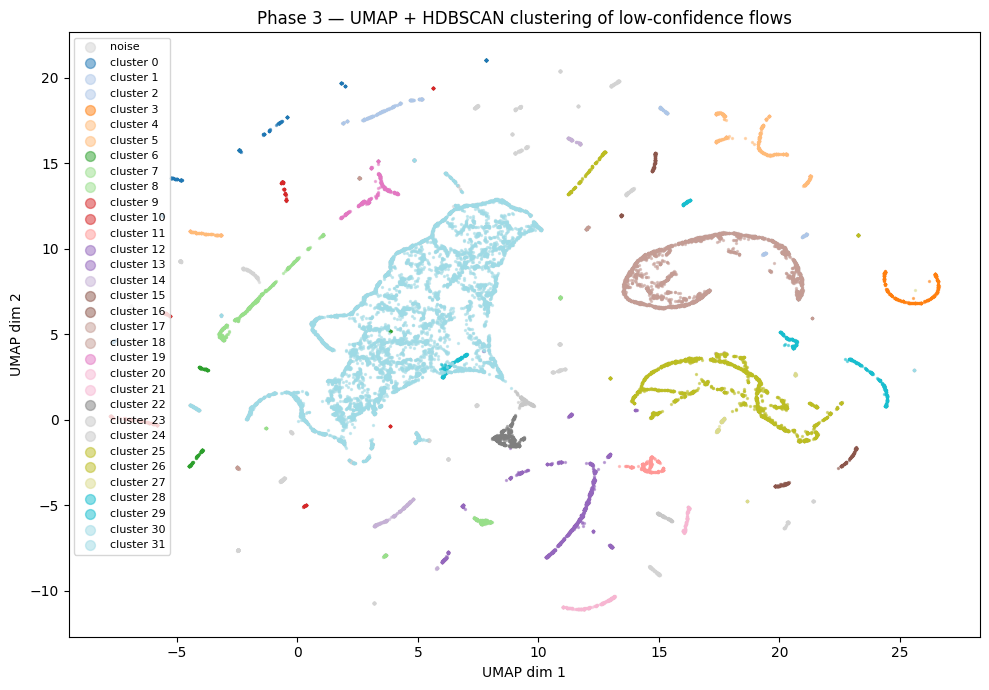

In [49]:
reducer_2d = umap.UMAP(
    n_components=2,
    n_neighbors=P3_UMAP_N_NEIGHBORS,
    min_dist=P3_UMAP_MIN_DIST,
    random_state=RANDOM_SEED,
)
X3_2d = reducer_2d.fit_transform(X3.values)

fig, ax = plt.subplots(figsize=(10, 7))
unique_labels = sorted(set(cluster_labels))
cmap = plt.cm.get_cmap("tab20", len(unique_labels))

for i, label in enumerate(unique_labels):
    mask = cluster_labels == label
    color = "lightgrey" if label == -1 else cmap(i)
    tag   = "noise" if label == -1 else f"cluster {label}"
    ax.scatter(X3_2d[mask, 0], X3_2d[mask, 1],
               c=[color], s=2, alpha=0.5, label=tag)

ax.set_title("Phase 3 — UMAP + HDBSCAN clustering of low-confidence flows")
ax.set_xlabel("UMAP dim 1")
ax.set_ylabel("UMAP dim 2")
ax.legend(markerscale=5, loc="best", fontsize=8)
plt.tight_layout()
plt.show()

In [50]:
dump(reducer,   "../models/umap_reducer.pkl")
dump(clusterer, "../models/hdbscan_clusterer.pkl")
print("Saved → ../models/umap_reducer.pkl")
print("Saved → ../models/hdbscan_clusterer.pkl")

Saved → ../models/umap_reducer.pkl
Saved → ../models/hdbscan_clusterer.pkl


In [51]:
_elapsed = _dt.now() - _report_start
_report_append(
    f"### Artifacts\n\n"
    f"| Artifact | Path |\n"
    f"|----------|------|\n"
    f"| UMAP reducer | `models/umap_reducer.pkl` |\n"
    f"| HDBSCAN clusterer | `models/hdbscan_clusterer.pkl` |\n\n"
    f"---\n\n"
    f"## Summary\n\n"
    f"| | |\n"
    f"|---|---|\n"
    f"| **Total training time** | `{str(_elapsed).split('.')[0]}` |\n"
    f"| **Phase 1 model** | `models/binary_classifier.pkl` |\n"
    f"| **Phase 1 threshold** | `{threshold}` → written to `scripts/network_binary_ids.py` |\n"
    f"| **Phase 2 model** | `models/multiclass_classifier.pkl` |\n"
    f"| **Phase 3 UMAP** | `models/umap_reducer.pkl` |\n"
    f"| **Phase 3 HDBSCAN** | `models/hdbscan_clusterer.pkl` |\n"
    f"| **Phase 1 best F2** | `{study.best_value:.4f}` |\n"
    f"| **Phase 2 best macro F1** | `{study_p2.best_value:.4f}` |\n"
    f"| **Phase 2 → Phase 3 routing** | `{(~known_mask).mean():.1%}` of flows |\n"
    f"| **Phase 3 clusters** | `{n_clusters}` |\n\n"
    f"*Generated by `notebooks/training.ipynb`*\n"
)
print(f"[report] Complete → {_report_path}")

[report] Complete → ../docs/results/training_20260517_115543.md
